In [2]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
# from generator import calculate_spectral_GF, systemInit, setup_ham_rse, calculate_spectral_density
from tqdm.auto import tqdm
import sisl
import h5py


import ipywidgets as widgets
from ipywidgets import interact, Dropdown, fixed, IntSlider, VBox, HBox
from mytools.plots import thesis_fig, label_subplots

import seaborn as sns
# sns.set_theme(style="white", context="notebook")

# REAL_PART_CMP = sns.color_palette("RdBu", as_cmap=True)

In [3]:
OUTPUTS = h5py.File("../conv_data/RSE_data.h5", 'r')
print(OUTPUTS.attrs.keys())
print(OUTPUTS.keys())
print(OUTPUTS["N_13"].keys())

<KeysViewHDF5 ['E', 'E0_idx', 'ETA', 'N', 'vmax', 'vmin']>
<KeysViewHDF5 ['N_13', 'N_17', 'N_21', 'N_9']>
<KeysViewHDF5 ['atoms_idx', 'elec_idx', 'eta_1.0e-01', 'eta_1.0e-03', 'eta_1.0e-04', 'eta_1.0e-05', 'xyz']>


In [ ]:
def plot_size_conv(data, N, E, eta, site, part, nn, nn_pair=False, global_minmax=False, axes=None):
    part = part.lower()
    current_N = data[f"N_{N}"]
    Energies = np.asanyarray(data.attrs["E"])
    xyz = np.asanyarray(current_N["xyz"])
    x,y,z = xyz.T
    
    elec_idx = np.asanyarray(current_N["elec_idx"])
    num_elec = len(elec_idx)    
    
    eta_key = "eta_{:.1e}".format(eta)
    E_mask = np.isclose(E, Energies, atol=1e-12)
    E_idx = np.argwhere(E_mask)[0,0]
    
    RSE = current_N[eta_key][E_idx, ...]
    
    if (part.lower() == "imag"):
        RSE = np.imag(RSE)
    elif (part.lower() == "real"):
        RSE = np.real(RSE)
        
    site_coupling = RSE[site, :]
    
    
    
    if global_minmax:
        vmin = data.attrs["vmin"]
        vmax = data.attrs["vmax"]
        vmax = np.max(np.abs([vmin, vmax]))
        vmin = -vmax
    else:
        vmax = np.max(np.abs(site_coupling))
        vmin = -vmax
    
    # calculate distance  
    all_coords = xyz
    site_coord = xyz[[site],:]
    electrode_coords = xyz[:N, :]
    site_mask = np.arange(xyz.shape[0])
    diff = all_coords[:, None, :] - site_coord[None, :, :] # (M, 1, N) - (1, K, N) = (M, K, L)
    diff_site = site_coord[:, None, :] - electrode_coords[None, :, :] # (1, 1, N) - (1, M, N) = (1, M, N)
    dists = np.linalg.norm(diff, axis=2).squeeze()
    dists_site = np.linalg.norm(diff_site, axis=2).squeeze()
    
    ylim = (vmin, 
            vmax
    )
    # calcualte xlim as the maximum distance to last atom on the side (from idx 0 to N-1)
    xlim = (-1, 
            np.max(
                np.linalg.norm(xyz[0, :] - xyz, axis=1)
            )
    )
    # start figure
    if axes is None:
        fig, axes = thesis_fig(subplots=(1,2), 
                               figsize=(10,4)
                               )
    else:
        fig = axes[1].get_figure()
        pass
    
    ### Left figure: scatter plot of distance and coupling 
    axes[0].scatter(dists[site_mask][:N], site_coupling[site_mask][:N], marker='+', color="b", s=15, label="1. edge") # plot points IN the first electrode side
    axes[0].scatter(dists[site_mask][N:num_elec], site_coupling[N:num_elec], marker="x", color="r", s=15, label="Other edges") # plot point in the OTHER electrodes
    axes[0].scatter(dists[site_mask][num_elec:], site_coupling[site_mask][num_elec:], marker='.', color="r", s=30, label="Device") # plot points not in the electrodes
    axes[0].legend()
    # mark the crossing of E=0
    axes[0].axhline(0, color="k",linestyle="--", linewidth=.8)
    
    # left axis params
    axes[0].set(
        xlabel=r"$r$ [$\mathrm{\AA}$]", 
                xlim=xlim,
                ylabel=rf"$\Sigma_{{{site}, j}}$", 
                ylim=ylim,
                title="Coupling Vs. distance"
    )
    
    # plot position colored by coupling
    sc = axes[1].scatter(x, y, c=site_coupling, vmin=vmin, vmax=vmax, cmap="RdBu", s=100/N)
    
    # right axis params
    axes[1].set(xlabel="$x$", 
                xticklabels="",
                ylabel="$y$",
                yticklabels="",
                title="Coupling in 2D",
    )
    
    # Plot site on right plot, and NN on both
    # nearest_neighbours = nn
    farthest_dist = 0
    for s in np.arange(site-nn, site+nn+1, 1):
        if (0 <= s) and (s < N): # s has to be in valid range 
            if s != site: # if it is not the site, plot on both
                farthest_dist=np.max([farthest_dist, dists[s]])
                axes[1].text(x=x[s], y=y[s]-1, s=s, horizontalalignment="right", verticalalignment="top")   
            elif s == site: # if it is site, plot with arrow on right
                axes[1].annotate(site, xy=(x[site], y[site]), xycoords="data", xytext=(x[site]+2*N/9, y[site]+3*N/9), arrowprops={"color":"k", "width":0.10, "headwidth":3.0, "headlength": 4.0}, )
    # if nn:
    
    farthest_nn_mask = np.nonzero(np.isclose(dists_site, farthest_dist, atol=1e-2))[0]
    if not nn_pair:
        farthest_nn_mask = farthest_nn_mask[[0]]
    
    
    axes[0].axvline(farthest_dist, color='k', linestyle="--", lw=1, alpha=0.5)
    
    coupling_for_farthest_nn = site_coupling[farthest_nn_mask]
    for coup in coupling_for_farthest_nn:
        axes[0].annotate(text=f" {coup:.1f}", xy=(farthest_dist, coup), xytext=(farthest_dist, coup))
    
    
    
    axes[1].axis("off")
    axes[0].grid(True, which="both", linestyle="-", lw=0.2)
    
    # Add colorbar (using divider to match the rescaled box)
    divider = make_axes_locatable(axes[1])
    cax = divider.append_axes("right", size="5%", pad=0.1)
    fig.colorbar(sc, cax, label=fr"$\Sigma_{{{site}, j}}$")
    
    
    # add a ghost axes to left of axes[0] forcing it to shrink 
    divider0 = make_axes_locatable(axes[0])
    spacer = divider0.append_axes("right", size="5%", pad=0.1)
    spacer.set_visible(False)
    spacer.set_axis_off()
    
    
    # return fig, axes
    

        

In [5]:
N_options = OUTPUTS.attrs["N"]
E_options = np.asanyarray(OUTPUTS.attrs["E"])
# E_options = np.where(np.isclose(E_options, 0, atol=1e-10), 0, E_options)
Eta_options = OUTPUTS.attrs["ETA"].round(6)
N_menu = Dropdown(value=N_options[0], options=N_options, description="Tiling, N =")
E_menu = Dropdown(value=E_options[len(E_options)//2], options=E_options, description="Energy [eV]")
Eta_menu = Dropdown(value=Eta_options[1], options=Eta_options, description="Eta", format=f":.1e")
site_slider = IntSlider(value=N_options[0]//2, min=0, max=int(N_options[0])-1, step=1, description="Site:")
neighbour_slider = IntSlider(value=1, min=0, max=np.max(np.abs([site_slider.max - site_slider.value,  site_slider.value])), step=1, description="Neighbours")
part_menu = Dropdown(value="imag", options=["real", "imag"], description="Part:")
show_nn_pair_box = widgets.Checkbox(value=False, description="Show pairs of NN")
use_minmax = widgets.Checkbox(value=False, description="Use global min/max")

def update_site_range(*args):
    new_n = int(N_menu.value) # if a new N is chosen, force update the IntSlider
    site_slider.max = new_n - 1 # set the max values of site_slider to N-1
    # neighbour_slider.max = np.abs(site_slider.max - site_slider.value)
    site_slider.value = site_slider.max // 2
    # if site_slider.value > site_slider.max: # if current site_slider value exceedes max, set to max
    #     site_slider.value = site_slider.max
    # if neighbour_slider.value > neighbour_slider.max:
    #     neighbour_slider.value = neighbour_slider.max
def update_nn_range(*args):
    new_site = int(site_slider.value)
    neighbour_slider.max = np.max(np.abs([site_slider.max - new_site, new_site]))
    if site_slider.value > site_slider.max:
        site_slider.value = site_slider.max
N_menu.observe(update_site_range, 'value') # 'observe' how N_menu's value changes
site_slider.observe(update_nn_range, 'value')


ui = widgets.VBox([
    widgets.HBox([N_menu, E_menu, Eta_menu]),
    widgets.HBox([site_slider, part_menu, use_minmax]),
    widgets.HBox([neighbour_slider, show_nn_pair_box]),
    # widgets.HBox([]),
])

out = widgets.interactive_output(plot_size_conv, {
    'data': fixed(OUTPUTS),
    'N': N_menu,
    'E': E_menu,
    'eta': Eta_menu,
    'site': site_slider,
    'part': part_menu,
    'nn': neighbour_slider,
    'nn_pair': show_nn_pair_box,
    'global_minmax': use_minmax,
})
display(ui, out)

Output()

0.0
0.0


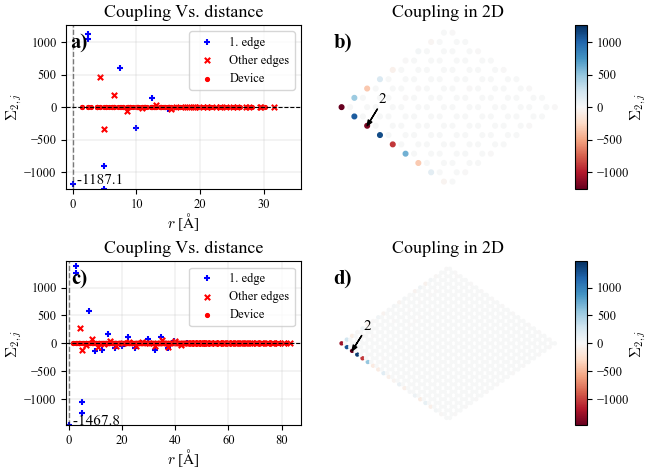

In [10]:
E = 0.
eta = 1e-3


fig, axes =  thesis_fig(subplots=(2,2), aspect=0.8)
plot_size_conv(OUTPUTS, N=9, E=E, eta=eta, site=2, 
               part="imag", nn=0, axes=axes[0, :])

plot_size_conv(OUTPUTS, N=21, E=E, eta=eta, site=2, 
               part="imag", nn=0, axes=axes[1, :])


labels = ['a)', 'b)', 'c)', 'd)']
flat_axes = axes.flatten()

# for i, ax in enumerate(flat_axes):
#     # x=-0.1, y=1.1 positions the label slightly outside the top-left corner
#     # transform=ax.transAxes ensures (0,0) is bottom-left and (1,1) is top-right of the plot
#     ax.text(0.09, 0.95, labels[i], transform=ax.transAxes,
#             fontsize=15, fontweight='bold', va='top', ha='right')
# fig.suptitle(f'$E -\\varepsilon_F= {E:.1f}$ eV,\t $\\eta = 10^{{{np.log10(eta):.0f}}}$')

label_subplots(axes=flat_axes)

fig.set_constrained_layout(True)
fig.savefig('../figures/size_comparison_coupling_site2')
fig.canvas.draw()

In [101]:
E_options[5]

np.longdouble('0.1')

In [118]:
E = -0.3
np.where(np.longdouble(E) == E_options)

(array([], dtype=int64),)